<p align="center"><img alt="BrBaLab" src="https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/logos/brbalab.png" width="64" height="64">&nbsp;&nbsp;&nbsp;&nbsp;<img alt="INRS" src="https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/logos/inrs.png" width="84" height="49">&nbsp;&nbsp;&nbsp;&nbsp;<img alt="Mitacs" src="https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/logos/mitacs.png" width="152" height="26">&nbsp;&nbsp;&nbsp;&nbsp;<img alt="Premier League" src="https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/logos/epl.png" width="38" height="64">&nbsp;&nbsp;&nbsp;&nbsp;<img alt="FIFA" src="https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/logos/fifa.png" width="112" height="37"></p>

# Pipeline BrBaLab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cortezxm/brbalab-cortez/blob/main/brbalab_pipeline.es.ipynb)

*English version: [`brbalab_pipeline.ipynb`](https://github.com/cortezxm/brbalab-cortez/blob/main/brbalab_pipeline.ipynb)*

De mayo a agosto de 2025 fui **intern de investigación Mitacs Globalink en el Institut national de la recherche scientifique (INRS), en Montreal, Quebec**, en el BrBaLab del
Prof. Leszek Szczecinski.

Cuando llegué, el backend era un script por liga, y cada uno mezclaba scraping, limpieza, rating, simulación y publicación; fue complicado entenderlo, ya que eran muchos archivos diferentes.
En equipo se convirtió en un **pipeline ETL por lotes, dividido en etapas**.

**Contenido**
0. Preparación
1. Punto de partida
2. El pipeline, de punta a punta
3. Extracción — scraping de 210 países
4. Transformación
5. El resultado conjunto — ratings y pronósticos de temporada
6. Idempotencia
7. Decisiones de diseño

## 0 · Preparación

Copia `backend/` a un directorio temporal, porque el pipeline escribe
archivos (estado de corrida, datos limpios, exportaciones) y el repositorio debe quedar intacto.

In [1]:
import os, sys, shutil, subprocess, tempfile, random, time
from pathlib import Path

import numpy as np
import pandas as pd

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not Path("brbalab-cortez").exists():
        subprocess.run(["git", "clone", "-q", "https://github.com/cortezxm/brbalab-cortez.git"], check=True)
    REPO = Path("brbalab-cortez").resolve()
else:
    REPO = Path.cwd().resolve()

WORK = Path(tempfile.mkdtemp()) / "backend"
shutil.copytree(REPO / "backend", WORK)
os.chdir(WORK)                      # the 2025 code uses paths relative to backend/
sys.path[:0] = [str(WORK), str(REPO)]

import processing.rating as rating
rating.TODAY = "2025-09-09"         # replay the season as it looked that day
np.random.seed(2025); random.seed(2025)

import viz
from IPython.display import Markdown, display

def show_source(path, start, lines=20):
    """Print a slice of a source file with its real line numbers."""
    text = (REPO / "backend" / path).read_text(encoding="utf-8").splitlines()
    first = next(i for i, l in enumerate(text) if start in l)
    body = "\n".join(f"{first + k + 1:>5}  {text[first + k]}" for k in range(min(lines, len(text) - first)))
    display(Markdown(f"`backend/{path}`\n```python\n{body}\n```"))

pd.set_option("display.width", 140)
print("pandas", pd.__version__, "| working copy:", WORK)

pandas 3.0.6 | working copy: /var/folders/cx/xvsv2qc94vb12k0z9m4ztdf00000gn/T/tmp3a08yfw8/backend


## 1 · Punto de partida

Las primeras semanas las dediqué a entender el sistema heredado antes de cambiarlo:

- **Un script por liga.** Scraping, limpieza, rating, simulación y la carga a Google Sheets vivían en el mismo archivo.
  Agregar una liga significaba copiar un script de varios cientos de líneas y editarlo a mano.
- **Nada corría por separado.** No se podía volver a correr una sola etapa ni saber cuál había fallado.

## 2 · El pipeline, de punta a punta

Se construyó un proceso ETL:

| Etapa | Código |
|---|---|
| **Extracción** — scrapear calendario y resultados | `acquisition/` |
| **Transformación** — validar, normalizar, deduplicar | `cleaning/` |
| **Rating y simulación** — ratings de Kalman, tabla de posiciones, Monte Carlo de 1,000 temporadas | `processing/` |
| **Carga** — publicar las tablas en Google Sheets | `export/` |
| **Orquestación** — correr las etapas y guardar el estado de corrida | `main.py` |

**Por qué etapas con un solo orquestador:** para avanzar en paralelo con mi compañero, volver a correr una sola etapa, depurar
más fácil y que cada módulo tenga una sola tarea. Las etapas se pasan un único DataFrame, `games_df`.

La siguiente celda corre el orquestador real. La única diferencia con producción: lee una copia fija de los datos y exporta a CSV
en vez de Google Sheets.

In [2]:
from main import DataPipelineOrchestrator

epl = DataPipelineOrchestrator(league="EPL", season_year=2025,
                               snapshot="EPL_data_files/EPL_snapshot_2025-09-09.csv", export_to="csv")
epl_results = epl.run_full_pipeline()

Initializing EPL Pipeline for season 2025-2026
STARTING EPL DATA PIPELINE
Run check: Last run 9140.5h ago (required: 24h)

[1/4] ACQUISITION: Loading EPL data...
   Loaded 380 games from snapshot EPL_data_files/EPL_snapshot_2025-09-09.csv
   Found 20 teams/countries
   Time: 0.00s

[2/4] CLEANING: Validating and cleaning data...
                                         id        date  gameweek               home_team                away_team  home_score  away_score
0          2025-08-15,Liverpool,Bournemouth  2025-08-15         1               Liverpool              Bournemouth           4           2
1      2025-08-16,Aston Villa,Newcastle Utd  2025-08-16         1             Aston Villa         Newcastle United           0           0
2            2025-08-16,Sunderland,West Ham  2025-08-16         1              Sunderland                 West Ham           3           0
3              2025-08-16,Tottenham,Burnley  2025-08-16         1               Tottenham                  Burnle

   Processed 380 games
   Time: 2.22s

[4/4] EXPORT: Exporting to CSV files...
   Wrote output/EPL_processed_data.csv, output/EPL_standings.csv
   Time: 0.01s
State saved: EPL last run updated

EPL PIPELINE COMPLETED SUCCESSFULLY

PIPELINE SUMMARY:
   Acquisition: 380 games, 20 teams/countries
   Cleaning: 380/380 games validated
   Total execution time: 2.23s


In [3]:
games = epl_results["processing"]["processed_data"]
standings = epl_results["processing"]["standings"]
current_week = int(games.loc[games["home_score"] >= 0, "gameweek"].max())   # last gameweek with results
current = standings[standings["week"] == current_week]
current[["league_rating", "team", "record", "points", "rating", "champion", "champions_league", "relegation_to_EFL"]].head(8)

,league_rating,team,record,points,rating,champion,champions_league,relegation_to_EFL
700,1,Liverpool,3-0-0,9,1106.044200,26.0,61.0,1.0
701,2,Chelsea,2-1-0,7,1059.973080,12.0,38.0,2.0
702,3,Sunderland,2-0-1,6,1025.205235,6.0,27.0,7.0
703,4,Tottenham,2-0-1,6,1031.248990,6.0,28.0,7.0
704,5,Bournemouth,2-0-1,6,1045.752033,10.0,35.0,4.0
705,6,Arsenal,2-0-1,6,1050.459482,8.0,33.0,4.0
706,7,Everton,2-0-1,6,1032.434232,6.0,28.0,5.0
707,8,Crystal Palace,1-2-0,5,1039.926479,6.0,28.0,5.0


## 3 · Extracción — scraping de 210 países miembros de la FIFA

Los resultados de selecciones salen de 11v11.com (Selenium) y el calendario de la EPL, de fbref. Una pasada completa de
FIFA duraba tanto que una falla significaba perder toda la corrida, así que diseñé esta capa alrededor de eso:

- **Estado de corrida por confederación** (`state.json`): FIFA se corre en seis partes independientes, y una falla en una no
  tira las demás.
- **Lotes de 10 países, cerrando Chrome entre lotes:** Chrome se colgaba tras muchas páginas y el sitio frenaba; navegadores
  nuevos y pausas mantenían vivas las corridas largas.

In [4]:
import ast
tree = ast.parse((REPO / "backend/acquisition/scraper.py").read_text(encoding="utf-8"))
countries = next(len(n.value.elts) for n in ast.walk(tree)
                 if isinstance(n, ast.Assign) and isinstance(n.value, ast.List)
                 and any(getattr(t, "id", None) == "FIFA_COUNTRIES_11V11" for t in n.targets))
print(f"Countries in the FIFA scraper: {countries}  ->  {-(-countries // 10)} batches of 10")
show_source("acquisition/scraper.py", "for batch_idx in range(0, len(FIFA_COUNTRIES_11V11)", lines=24)

Countries in the FIFA scraper: 210  ->  21 batches of 10


`backend/acquisition/scraper.py`
```python
 1352                  for batch_idx in range(0, len(FIFA_COUNTRIES_11V11), FIFAConfig.BATCH_SIZE):
 1353                      batch_num = (batch_idx // FIFAConfig.BATCH_SIZE) + 1
 1354                      batch_countries = FIFA_COUNTRIES_11V11[batch_idx:batch_idx + FIFAConfig.BATCH_SIZE]
 1355                      
 1356                      logger.info(f"Processing batch {batch_num}/{total_batches}: {len(batch_countries)} countries")
 1357                      
 1358                      with PerformanceTimer(f"batch {batch_num}"):
 1359                          ChromeProcessManager.kill_all_chrome_processes()
 1360                          
 1361                          batch_matches = self.scrape_countries_batch(batch_countries, str(self.season_year))
 1362                          
 1363                          all_matches.extend(batch_matches)
 1364                          
 1365                          logger.info(f"Batch {batch_num} completed: {len(batch_matches)} matches collected")
 1366                          
 1367                          ChromeProcessManager.kill_all_chrome_processes()
 1368                          
 1369                          if batch_num < total_batches:
 1370                              time.sleep(10)
 1371                  
 1372                  ChromeProcessManager.kill_all_chrome_processes()
 1373                  
 1374                  self.venue_tracker.save_all_venue_files()
 1375                  
```

**Así se veía corriendo.** El código de 2025, grabado en vivo en 11v11.com: el log a la izquierda y Chrome a la derecha,
abriendo cada una de las 19 páginas de partidos de México, con Chrome cerrándose y reabriéndose entre páginas. Duró 3 min 15 s
y se muestra a ×14. Videos completos: [scraper de FIFA, ×8](https://github.com/cortezxm/brbalab-cortez/blob/main/assets/fifa_scraper.mp4) ·
[scraper de la EPL](https://github.com/cortezxm/brbalab-cortez/blob/main/assets/epl_scraper.mp4).

![Scraper de FIFA corriendo en vivo](https://raw.githubusercontent.com/cortezxm/brbalab-cortez/main/assets/fifa_scraper.gif)

**Tiempos del log de producción.** El pipeline corría a diario en la máquina Windows del laboratorio, y su log
(`backend/run_log.txt`, del 29 de agosto al 9 de septiembre de 2025) es la única fuente de tiempos registrada. La siguiente celda lo lee.

In [5]:
import re
log = (REPO / "backend/run_log.txt").read_text(encoding="utf-8", errors="replace").splitlines()
done = re.compile(r"^(\S+ \S+),\d+ - acquisition\.scraper - INFO - Completed (EPL|FIFA) scraping in ([\d.]+) seconds")
runs = []
for i, line in enumerate(log):
    m = done.match(line)
    if not m:
        continue
    name = next((l.replace("Initializing ", "").split(" Pipeline")[0] for l in log[i:i + 15] if l.startswith("Initializing")), m[2])
    runs.append({"finished": m[1], "pipeline": name, "scrape_min": round(float(m[3]) / 60, 1)})
runs = pd.DataFrame(runs)
print(runs.groupby("pipeline")["scrape_min"].describe()[["count", "min", "max"]])
runs[runs.pipeline.str.startswith("FIFA")]

                 count   min   max
pipeline                          
EPL               12.0   0.1   0.3
FIFA (CONMEBOL)    5.0  51.0  79.5


,finished,pipeline,scrape_min
8,2025-09-05 06:10:59,FIFA (CONMEBOL),70.9
10,2025-09-06 06:16:04,FIFA (CONMEBOL),76.0
12,2025-09-07 06:08:18,FIFA (CONMEBOL),68.2
14,2025-09-08 06:19:36,FIFA (CONMEBOL),79.5
16,2025-09-09 05:51:06,FIFA (CONMEBOL),51.0


Scrapear **los 10 países de CONMEBOL tomó de 51 a 80 minutos** por corrida: unos 5–8 minutos por país, con pausas y navegadores
nuevos. La EPL, una sola página por temporada, tomó segundos.

**Ventana e historial.** Cada corrida de FIFA vuelve a recolectar los partidos desde el **2023-01-01**.

In [6]:
import json
print(json.dumps(epl.load_state(), indent=2))
print("Should EPL run again now? ->", epl.check_should_run("EPL"))

{
  "last_run": {
    "EPL": "2026-09-25T00:32:50.355318",
    "FIFA": null
  }
}
Should EPL run again now? -> (False, 'Too soon - 24.0h remaining')


## 4 · Transformación — la capa de limpieza

Mi primera versión fue un solo `data_cleaner.py`. Después lo dividí en una clase base con una subclase por fuente, porque cada
fuente se ensucia a su manera y la lógica compartida (validación, respaldos, registro de filas eliminadas) debía vivir en un solo lugar:

```
BaseDataCleaner                 compartido
├── EPLDataCleaner              fbref: nombres de equipos, jornadas, partidos sin jugar (-1/-1)
└── FIFADataCleaner             11v11: textos de resultado, penales/tiempo extra, walkovers, canchas neutrales, códigos FIFA
```

In [7]:
from cleaning.fifa_cleaner import FIFADataCleaner

raw = pd.read_csv("FIFA_data_files/AllGames_raw.csv")
shutil.copy("FIFA_data_files/AllGames_raw.csv", "fifa_demo.csv")      # the cleaner rewrites its input file
fifa_cleaner = FIFADataCleaner()
_, fifa_clean = fifa_cleaner.clean_data("fifa_demo.csv")

removed = pd.DataFrame(fifa_cleaner.removed_rows)
print(f"raw rows: {len(raw)}   clean rows: {len(fifa_clean)}   removed: {len(removed)}")
removed["reason"].value_counts()

   Loaded 6916 games from fifa_demo.csv
   Saved 6877 cleaned games to fifa_demo.csv
raw rows: 6916   clean rows: 6877   removed: 39


reason
duplicate_game      35
final_validation     4
Name: count, dtype: int64

La mayoría de las eliminaciones son **duplicados espejo**: el mismo partido guardado dos veces, con local y visitante invertidos
y una etiqueta de competición distinta según la fuente. La limpieza los detecta porque su clave de partido ordena a los dos equipos:

In [8]:
key = raw["date"] + "," + raw[["home_team", "away_team"]].apply(lambda r: ",".join(sorted(r)), axis=1)
mirrored = raw[key.duplicated(keep=False)].assign(key=key).sort_values(["key", "home_team"])
mirrored[["date", "home_team", "away_team", "result", "competition", "neutral_pitch"]].head(6)

,date,home_team,away_team,result,competition,neutral_pitch
4581,2023-08-02,ETH,GUY,2:0,International Friendly -,True
4582,2023-08-02,GUY,ETH,0:2,Friendly 2023,True
4634,2023-09-08,CRC,KSA,3:1,International Friendly -,True
4651,2023-09-08,KSA,CRC,1:3,Friendly 2023,True
4670,2023-09-09,RWA,SEN,1:1,Africa Cup of Nations Qualifying group L,False
4682,2023-09-09,SEN,RWA,1:1,CAF Nations Cup 2023 Q,False


**Filas sucias a propósito.** Se inyectan cinco problemas típicos en una muestra real —una fecha inválida, un partido adjudicado, un marcador irreal, un partido aplazado y un duplicado espejo— y la limpieza detecta cada uno:

In [9]:
DIRTY = {
    "Invalid date":             {"date": "2025-13-45", "home_team": "MEX", "away_team": "USA", "result": "2:0"},
    "Awarded match (walkover)": {"date": "2025-06-01", "home_team": "CAN", "away_team": "PAN", "result": "3:0 awarded"},
    "Unrealistic score":        {"date": "2025-06-02", "home_team": "BRA", "away_team": "PER", "result": "40:0"},
    "Postponed":                {"date": "2025-06-03", "home_team": "ARG", "away_team": "CHI", "result": "postponed"},
}
sample = raw.sample(8, random_state=1).copy()
base = sample.iloc[0].to_dict()
mirror = {**base, "home_team": base["away_team"], "away_team": base["home_team"]}
dirty = pd.concat([sample, pd.DataFrame([{**base, **row} for row in DIRTY.values()] + [mirror])], ignore_index=True)
dirty["index"] = range(len(dirty))
dirty.to_csv("dirty_demo.csv", index=False)

demo = FIFADataCleaner()
_, clean = demo.clean_data("dirty_demo.csv")
print(f"{len(dirty)} rows in (8 real + 5 dirty)  ->  {len(clean)} rows out")
caught = pd.DataFrame(demo.removed_rows)
caught["row"] = caught["data"].map(lambda d: f"{d.get('date')} {d.get('home_team')}-{d.get('away_team')} {d.get('result', '')}")
caught[["reason", "row"]]

   Loaded 13 games from dirty_demo.csv


   Saved 8 cleaned games to dirty_demo.csv
13 rows in (8 real + 5 dirty)  ->  8 rows out


,reason,row
0,invalid_result,2025-06-01 CAN-PAN 3:0 awarded
1,invalid_result,2025-06-02 BRA-PER 40:0
2,invalid_result,2025-06-03 ARG-CHI postponed
3,invalid_date,2025-13-45 MEX-USA 2:0
4,duplicate_game,2025-06-05 FRO-GEO 1:0


## 5 · El resultado conjunto — ratings y pronósticos de temporada

Aquí mis capas alimentan las de mi compañero: el `games_df` limpio pasa por el rating de Kalman y la simulación Monte Carlo. Estos son
los resultados que publicaba el laboratorio.

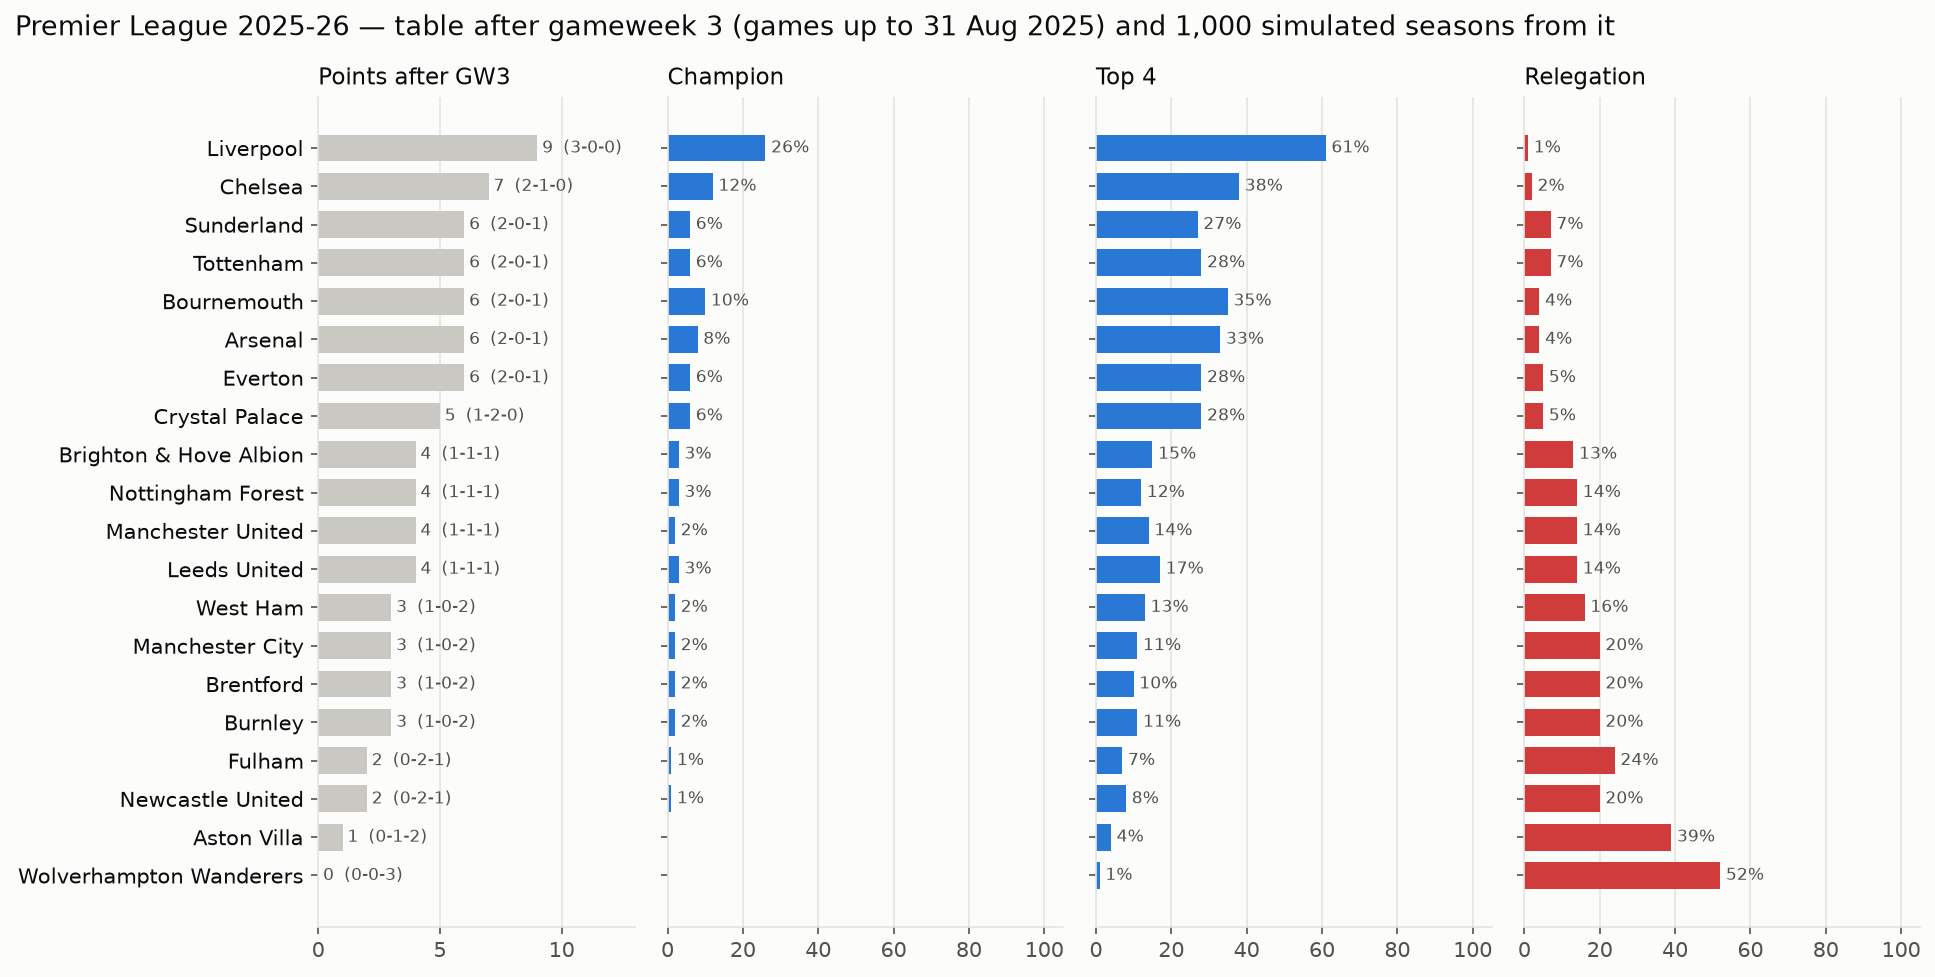

In [10]:
last_played = pd.to_datetime(games.loc[games["home_score"] >= 0, "date"]).max()
viz.save_light_dark(lambda mode: viz.season_simulation_figure(current, current_week, last_played, mode),
                    "epl_season_simulation", out_dir=REPO / "assets")
fig = viz.season_simulation_figure(current, current_week, last_played, "light")

Initializing FIFA Pipeline for season 2025-2026
STARTING FIFA DATA PIPELINE
Run check: First run

[1/4] ACQUISITION: Loading FIFA data...
   Loaded 6916 games from snapshot FIFA_data_files/AllGames_raw.csv
   Found 220 teams/countries
   Time: 0.00s

[2/4] CLEANING: Validating and cleaning data...
   Loaded 6916 games from FIFA_data_files/AllGames.csv
   Saved 6877 cleaned games to FIFA_data_files/AllGames.csv
   Processed 6916 games
   Cleaned 6877 games
   Removed 39 invalid games
   Time: 0.12s

[3/4] PROCESSING: Calculating ratings and predictions...
Updating ratings


   Processed 6877 games
   Time: 12.94s

[4/4] EXPORT: Exporting to CSV files...
   Wrote output/FIFA_processed_data.csv
   Time: 0.04s
State saved: FIFA last run updated

FIFA PIPELINE COMPLETED SUCCESSFULLY

PIPELINE SUMMARY:
   Acquisition: 6916 games, 220 teams/countries
   Cleaning: 6877/6916 games validated
   Total execution time: 13.10s


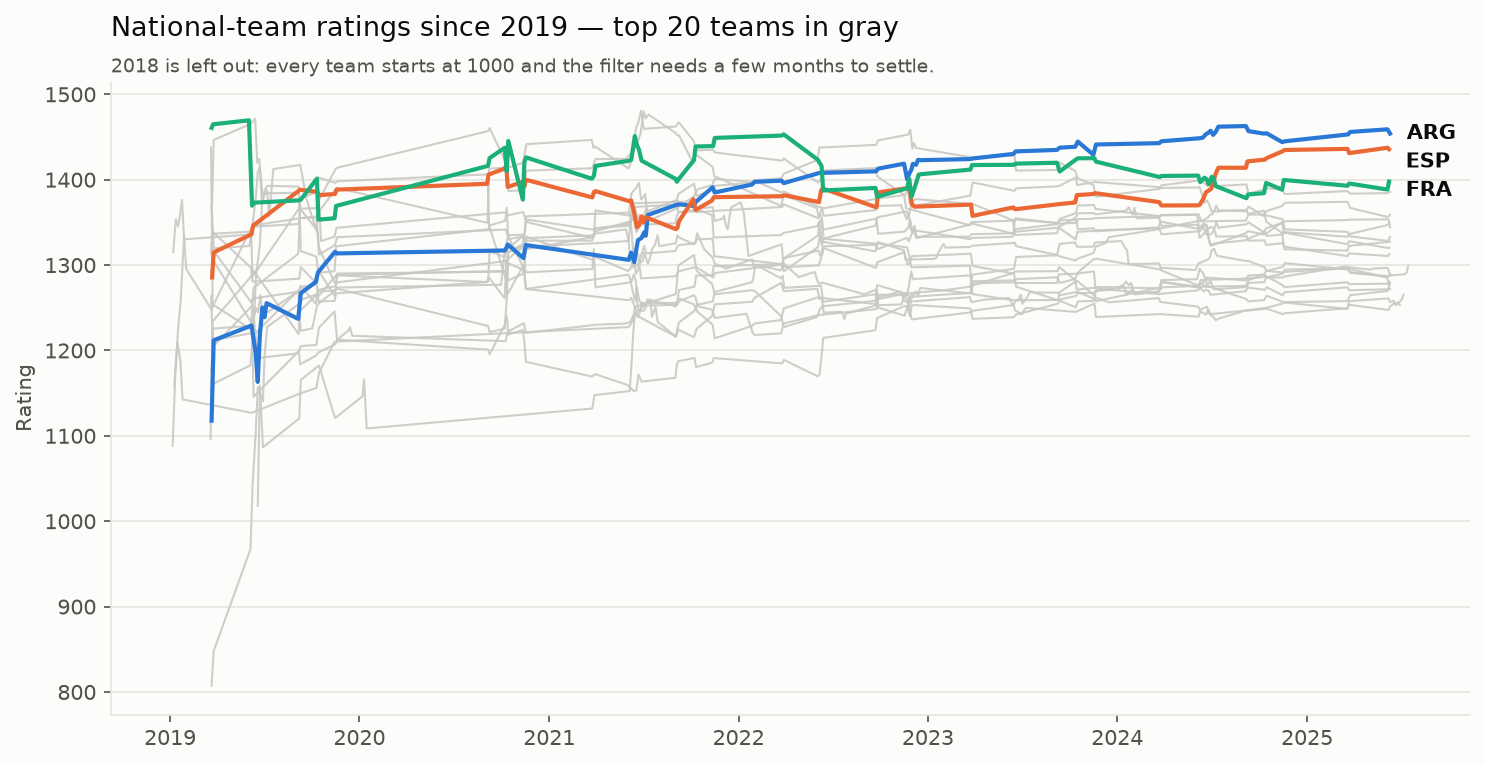

In [11]:
fifa = DataPipelineOrchestrator(league="FIFA", season_year=2025,
                                snapshot="FIFA_data_files/AllGames_raw.csv", export_to="csv")
fifa_results = fifa.run_full_pipeline()
history = viz.team_rating_history(fifa_results["processing"]["processed_data"])
top3 = history.groupby("team").tail(1).nlargest(3, "rating")["team"].tolist()
viz.save_light_dark(lambda mode: viz.fifa_ratings_figure(history, top3, mode=mode), "fifa_ratings", out_dir=REPO / "assets")
fig = viz.fifa_ratings_figure(history, top3)

## 6 · Idempotencia

Un proceso programado a diario vuelve a leer datos que ya vio, así que una segunda corrida no debe duplicar ni corromper nada.
Limpiar datos ya limpios devuelve las mismas filas:

In [12]:
second = FIFADataCleaner()
_, twice = second.clean_data("fifa_demo.csv")     # fifa_demo.csv now holds the cleaned output
print(f"first pass: {len(fifa_clean)} rows   second pass: {len(twice)} rows   removed on second pass: {len(second.removed_rows)}")
assert len(twice) == len(fifa_clean)

   Loaded 6877 games from fifa_demo.csv


   Saved 6877 cleaned games to fifa_demo.csv
first pass: 6877 rows   second pass: 6877 rows   removed on second pass: 0


El log de producción muestra la misma propiedad del lado del scraper. Cada corrida volvió a recolectar 102 partidos que ya tenía,
y el merge descartó los 102 (`6916 historical + 102 new = 6916 total`).

In [13]:
print("\n".join(l for l in log if "Merged dataset" in l or "Removed 102 duplicate" in l))

2025-09-05 06:10:59,868 - acquisition.scraper - INFO - Removed 102 duplicate matches
2025-09-05 06:10:59,870 - acquisition.scraper - INFO - Merged dataset: 6916 historical + 102 new = 6916 total
2025-09-06 06:16:04,589 - acquisition.scraper - INFO - Removed 102 duplicate matches
2025-09-06 06:16:04,589 - acquisition.scraper - INFO - Merged dataset: 6916 historical + 102 new = 6916 total
2025-09-07 06:08:18,688 - acquisition.scraper - INFO - Removed 102 duplicate matches
2025-09-07 06:08:18,688 - acquisition.scraper - INFO - Merged dataset: 6916 historical + 102 new = 6916 total
2025-09-08 06:19:36,821 - acquisition.scraper - INFO - Removed 102 duplicate matches
2025-09-08 06:19:36,821 - acquisition.scraper - INFO - Merged dataset: 6916 historical + 102 new = 6916 total
2025-09-09 05:51:06,430 - acquisition.scraper - INFO - Removed 102 duplicate matches
2025-09-09 05:51:06,430 - acquisition.scraper - INFO - Merged dataset: 6916 historical + 102 new = 6916 total


## 7 · Decisiones de diseño

**Scraping en vez de una API de datos.** Propuse usar una API, pero no era viable: ninguna API gratuita cubría el historial de unas
210 selecciones, las de pago no entraban en el presupuesto. El costo de scrapear
se ve en la sección 3: de 5 a 8 minutos por país con Selenium, dependencia del HTML de terceros y, hoy, bloqueos de Cloudflare.
Hoy usaría una API como fuente principal si hay presupuesto, y el scraping solo como respaldo.

**Archivos CSV en vez de una base de datos.** Propuse SQLite, pero el laboratorio prefirió archivos planos. Mi argumento sigue siendo
el mismo: SQLite es un solo archivo, sin servidor, y una llave única sobre (fecha, equipos ordenados) habría hecho imposibles los
duplicados espejo de la sección 4.

**Google Sheets en vez de una API propia.** El frontend del sitio ya leía Google Sheets; esa era la interfaz acordada entre capas.
Una API propia (FastAPI, Flask) habría sido otra pieza que mantener, sin nadie que la consumiera.

**Sin tests.** Por tiempo: se priorizaron las funcionalidades y la validación fue manual, contra datos reales, en las demos semanales.

**Un scraper de 1,459 líneas que cierra todos los Chrome de la máquina.** Creció a base de parches: cada problema (cuelgues, bloqueos,
sedes) se resolvió agregando código al mismo archivo. Cerrar todos los procesos de Chrome
([`scraper.py:300`](https://github.com/cortezxm/brbalab-cortez/blob/main/backend/acquisition/scraper.py#L300)) era aceptable porque la mini-PC solo corría esto; en cualquier
otra máquina cerraría el navegador de quien la estuviera usando. Hoy lo separaría en un módulo por sitio y cerraría solo los procesos
que abrió el driver.